<a href="https://colab.research.google.com/github/karodeakshat064/machine-learning-csit/blob/main/Another_copy_of_Convolutional_Neural_Networks_for_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>









# Part 1: Convolutional Neural Network

###  Importing packages

In [1]:
import numpy as np
import keras
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D
from keras import backend as K
from keras.preprocessing import image
from keras.applications.mobilenet import MobileNet
from keras.applications.vgg16 import preprocess_input, decode_predictions
from keras.models import Model
import timeit

import warnings
warnings.filterwarnings('ignore')

### Preparing Dataset

In [2]:
batch_size = 128
num_classes = 10
epochs = 1

# input image dimensions
img_rows, img_cols = 28, 28

# the data, shuffled and split between train and test sets
(x_train, y_train), (x_test, y_test) = mnist.load_data()

if K.image_data_format() == 'channels_first':
    x_train = x_train.reshape(x_train.shape[0], 1, img_rows, img_cols)
    x_test = x_test.reshape(x_test.shape[0], 1, img_rows, img_cols)
    input_shape = (1, img_rows, img_cols)
else:
    x_train = x_train.reshape(x_train.shape[0], img_rows, img_cols, 1)
    x_test = x_test.reshape(x_test.shape[0], img_rows, img_cols, 1)
    input_shape = (img_rows, img_cols, 1)

x_train = x_train.astype('float32')
x_test = x_test.astype('float32')
x_train /= 255
x_test /= 255
print('x_train shape:', x_train.shape)
print(x_train.shape[0], 'train samples')
print(x_test.shape[0], 'test samples')

# convert class vectors to binary class matrices
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
x_train shape: (60000, 28, 28, 1)
60000 train samples
10000 test samples


### Building a Model

In [3]:
model = Sequential()
model.add(Conv2D(8, kernel_size=(3, 3), activation='relu', input_shape=input_shape))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(16, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))
model.add(Flatten())
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(num_classes, activation='softmax'))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 5, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │        12,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,410 (56.29 KB)

 Trainable params: 14,410 (56.29 KB)

 Non-trainable params: 0 (0.00 B)

### Model Training

In [4]:
model.compile(loss=keras.losses.categorical_crossentropy,
              optimizer=keras.optimizers.Adadelta(),
              metrics=['accuracy'])

model.fit(x_train, y_train,
          batch_size=batch_size,
          epochs=epochs,
          verbose=1,
          validation_data=(x_test, y_test))

469/469 ━━━━━━━━━━━━━━━━━━━━ 31s 58ms/step - accuracy: 0.1091 - loss: 2.3099 - val_accuracy: 0.1020 - val_loss: 2.2944


### Testing

In [5]:
score = model.evaluate(x_test, y_test, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

Test loss: 2.2943530082702637
Test accuracy: 0.10199999809265137


### Prediction

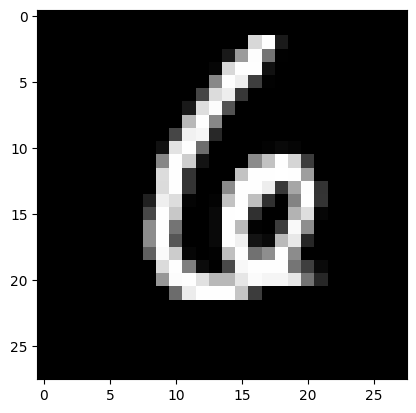

In [6]:
import pylab as plt

plt.imshow(x_test[123].reshape(28,28),cmap='gray')
plt.show()

In [7]:
import numpy as np
prediction = model.predict(x_test[123:124])
print('Prediction Score:\n',prediction[0])
thresholded = (prediction>0.5)*1
print('\nThresholded Score:\n',thresholded[0])
#print('\nPredicted Digit:\n',np.where(thresholded == 1)[1][0])

predicted_digit = np.argmax(prediction[0])
print(predicted_digit)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
Prediction Score:
 [0.07064043 0.10129426 0.08879192 0.13077077 0.11240764 0.0859163
 0.0848593  0.11105231 0.11098853 0.10327852]

Thresholded Score:
 [0 0 0 0 0 0 0 0 0 0]
3


# Part 2: Applications of Convolutional Neural Network

###  MobileNet Models

In [8]:
model = MobileNet(input_shape=None, alpha=0.25, depth_multiplier=1, dropout=1e-3,
                                 include_top=True, weights='imagenet', input_tensor=None, pooling=None, classes=1000)

model.summary()

2108140/2108140 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "mobilenet_0.25_224"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 112, 112, 8)    │           216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_bn (BatchNormalization)   │ (None, 112, 112, 8)    │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_relu (ReLU)               │ (None, 112, 112, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1 (DepthwiseConv2D)     │ (None, 112, 112, 8)    │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_bn                    │ (None, 112, 112, 8)    │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_relu (ReLU)           │ (None, 112, 112, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1 (Conv2D)              │ (None, 112, 112, 16)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_bn                    │ (None, 112, 112, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_relu (ReLU)           │ (None, 112, 112, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pad_2 (ZeroPadding2D)      │ (None, 113, 113, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2 (DepthwiseConv2D)     │ (None, 56, 56, 16)     │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_bn                    │ (None, 56, 56, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_relu (ReLU)           │ (None, 56, 56, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2 (Conv2D)              │ (None, 56, 56, 32)     │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_bn                    │ (None, 56, 56, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_relu (ReLU)           │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3 (DepthwiseConv2D)     │ (None, 56, 56, 32)     │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_bn                    │ (None, 56, 56, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_relu (ReLU)           │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3 (Conv2D)              │ (None, 56, 56, 32)     │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3_bn                    │ (None, 56, 56, 32)     │           128 │
│ (BatchNormalization)            │                        │             

 Total params: 475,544 (1.81 MB)

 Trainable params: 470,072 (1.79 MB)

 Non-trainable params: 5,472 (21.38 KB)

In [10]:
import requests
from PIL import Image
from io import BytesIO

# Download a sample image
image_url = 'https://images.pexels.com/photos/1644403/pexels-photo-1644403.jpeg?auto=compress&cs=tinysrgb&dpr=1&w=500'
response = requests.get(image_url)
img_data = Image.open(BytesIO(response.content))
img_data.save('dog.jpg')

print('Sample image "dog.jpg" downloaded.')

Sample image "dog.jpg" downloaded.


###  Classify images

In [9]:
# Write the image name below

img_path = '.jpg'
img = image.load_img(img_path, target_size=(224, 224))
x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)
x = preprocess_input(x)

preds = model.predict(x)
print('Predicted:\n', decode_predictions(preds))

FileNotFoundError: [Errno 2] No such file or directory: '.jpg'

In [11]:
# Write the image name below

img_path = 'dog.jpg'
img = image.load_img(img_path, target_size=(224, 224))
x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)
x = preprocess_input(x)

preds = model.predict(x)
print('Predicted:\n', decode_predictions(preds))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Predicted:
 [[('n06359193', 'web_site', np.float32(0.1432233)), ('n02708093', 'analog_clock', np.float32(0.043442078)), ('n04275548', 'spider_web', np.float32(0.04082876)), ('n04476259', 'tray', np.float32(0.03345698)), ('n04548280', 'wall_clock', np.float32(0.031524997))]]


###  Extract CNN features

In [12]:
features = model.predict(x)
print('\nFeature Shape:\n',features.shape)
print('\nFeatures:\n',features)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step

Feature Shape:
 (1, 1000)

Features:
 [[3.64598520e-07 9.21727769e-05 4.12653841e-04 1.72481887e-05
  1.06959000e-04 1.71426618e-05 9.94522725e-06 6.30344448e-06
  9.48857576e-07 1.27804751e-05 2.29535743e-07 1.15491434e-06
  3.65896369e-07 1.91080062e-06 4.88633850e-05 3.20995287e-06
  8.25241113e-06 3.04229184e-06 6.82943573e-06 8.24904760e-07
  5.61520710e-06 2.09011523e-06 1.41615719e-05 1.25214028e-05
  1.01941536e-04 6.36845130e-07 6.89040144e-06 1.33474987e-05
  1.34475590e-06 1.89584011e-06 3.21655671e-06 3.79860430e-05
  2.12294458e-06 1.94440577e-06 6.00384828e-06 3.48738945e-06
  9.32302373e-06 1.90078154e-07 8.30801855e-06 7.05856437e-05
  7.87071040e-05 7.84440454e-06 1.45991580e-05 2.37409154e-06
  1.76080050e-06 1.05190043e-06 9.57809680e-05 5.90142045e-05
  4.56437988e-07 5.13440646e-05 1.46171777e-04 7.86325245e-07
  5.13714838e-07 7.22565937e-06 3.11577594e-07 3.52529096e-05
  4.47187540e-06 5.64509754e-08 1.21071098e-05 1.143617

###  Extract features from an arbitrary intermediate layer

In [14]:
model_minimal = Model(inputs=model.input, outputs=model.get_layer('conv_dw_2_relu').output)

conv_dw_2_relu_features = model_minimal.predict(x)
print('Features of conv_dw_2_relu:',conv_dw_2_relu_features.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step
Features of conv_dw_2_relu: (1, 56, 56, 16)


### You can extract these features and use the base network as a feature extractor for your problems.

# Part 3: Deep Convolution Layer Visualization

In [17]:
import matplotlib as mp
%matplotlib inline
import matplotlib.pyplot as plt
import tensorflow as tf
import math
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np # Ensure numpy is imported for general use

### Extract Data

In [18]:
(x_train_mnist, y_train_mnist), (x_test_mnist, y_test_mnist) = keras.datasets.mnist.load_data()

# Preprocess the MNIST data similar to how it was done for the Keras model earlier
img_rows, img_cols = 28, 28 # MNIST image dimensions

# Reshape data to include channel dimension
x_train_mnist = x_train_mnist.reshape(x_train_mnist.shape[0], img_rows, img_cols, 1)
x_test_mnist = x_test_mnist.reshape(x_test_mnist.shape[0], img_rows, img_cols, 1)

x_train_mnist = x_train_mnist.astype('float32') / 255.0
x_test_mnist = x_test_mnist.astype('float32') / 255.0

# Convert class vectors to binary class matrices
num_classes_mnist = 10
y_train_mnist = keras.utils.to_categorical(y_train_mnist, num_classes_mnist)
y_test_mnist = keras.utils.to_categorical(y_test_mnist, num_classes_mnist)

print('x_train_mnist shape:', x_train_mnist.shape)
print(x_train_mnist.shape[0], 'train samples')
print(x_test_mnist.shape[0], 'test samples')

x_train_mnist shape: (60000, 28, 28, 1)
60000 train samples
10000 test samples


### Model Building

In [26]:
# Clear any previous Keras session
keras.backend.clear_session()

model_tf2 = keras.Sequential([
    layers.Conv2D(5, (5, 5), activation='relu', input_shape=(28, 28, 1), padding='same'), # hidden_1
    layers.MaxPooling2D((2, 2)), # pool_1
    layers.Conv2D(5, (5, 5), activation='relu', padding='same'), # hidden_2
    layers.MaxPooling2D((2, 2)), # pool_2
    layers.Conv2D(20, (5, 5), activation='relu', padding='same'), # hidden_3
    layers.Dropout(0.5), # dropout after hidden_3
    layers.Flatten(),
    layers.Dense(num_classes_mnist, activation='softmax') # out_y
])

model_tf2.summary()

# Compile the model
model_tf2.compile(optimizer=keras.optimizers.Adam(1e-4),
                  loss=keras.losses.CategoricalCrossentropy(),
                  metrics=['accuracy'])

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 5)      │           130 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 5)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 5)      │           630 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 5)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 20)       │         2,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 7, 7, 20)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 980)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         9,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,090 (51.13 KB)

 Trainable params: 13,090 (51.13 KB)

 Non-trainable params: 0 (0.00 B)

batchSize = 50
epochs_tf2 = 1 # Using 1 epoch for quick demonstration

history = model_tf2.fit(x_train_mnist, y_train_mnist,
                        batch_size=batchSize,
                        epochs=epochs_tf2,
                        verbose=1,
                        validation_data=(x_test_mnist, y_test_mnist))

In [ ]:
batchSize = 50
sess = tf.Session()
init = tf.global_variables_initializer()
sess.run(init)
for i in range(1001):
    batch = mnist.train.next_batch(batchSize)
    sess.run(train_step, feed_dict={x:batch[0],true_y:batch[1], keep_prob:0.5})
    if i % 100 == 0 and i != 0:
        trainAccuracy = sess.run(accuracy, feed_dict={x:batch[0],true_y:batch[1], keep_prob:1.0})
        print("step %d, training accuracy %g"%(i, trainAccuracy))

### Testing accuracy

In [28]:
score_tf2 = model_tf2.evaluate(x_test_mnist, y_test_mnist, verbose=0)
print('Test loss:', score_tf2[0])
print('Test accuracy:', score_tf2[1])

Test loss: 2.311957359313965
Test accuracy: 0.09640000015497208


### Get activation values and plotting

In [27]:
def getActivations(model_keras, layer_name, stimuli):
    # Create a new model that outputs the activations of the specified layer
    # Use model_keras.layers[0].input for robustness with Sequential models
    intermediate_model = keras.Model(inputs=model_keras.layers[0].input,
                                     outputs=model_keras.get_layer(layer_name).output)
    # Predict activations for the input stimuli
    # Reshape stimuli to add batch dimension if it's a single image
    if stimuli.ndim == 3: # (height, width, channels)
        stimuli = np.expand_dims(stimuli, axis=0) # Add batch dimension

    activations = intermediate_model.predict(stimuli)
    plotNNFilter(activations)

def plotNNFilter(units):
    # units shape is (batch_size, height, width, filters)
    filters = units.shape[3]
    plt.figure(1, figsize=(20, 20))
    n_columns = 6
    n_rows = math.ceil(filters / n_columns)
    for i in range(filters):
        plt.subplot(n_rows, n_columns, i + 1)
        plt.title('Filter ' + str(i))
        # Remove batch dimension for plotting
        plt.imshow(units[0, :, :, i], interpolation="nearest", cmap="gray")
    plt.show()

### Input Image

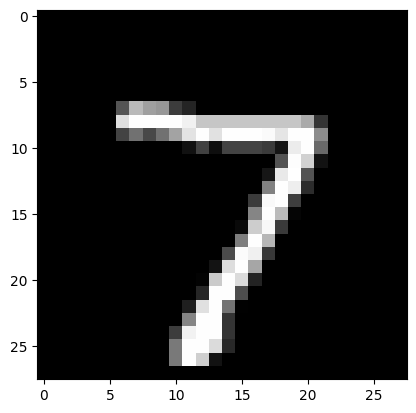

In [29]:
# Using the preprocessed x_test_mnist
imageToUse_tf2 = x_test_mnist[0] # This will be (28, 28, 1)
plt.imshow(imageToUse_tf2.reshape(28, 28), interpolation="nearest", cmap="gray")
plt.show()

### Activation in Layer 1

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step


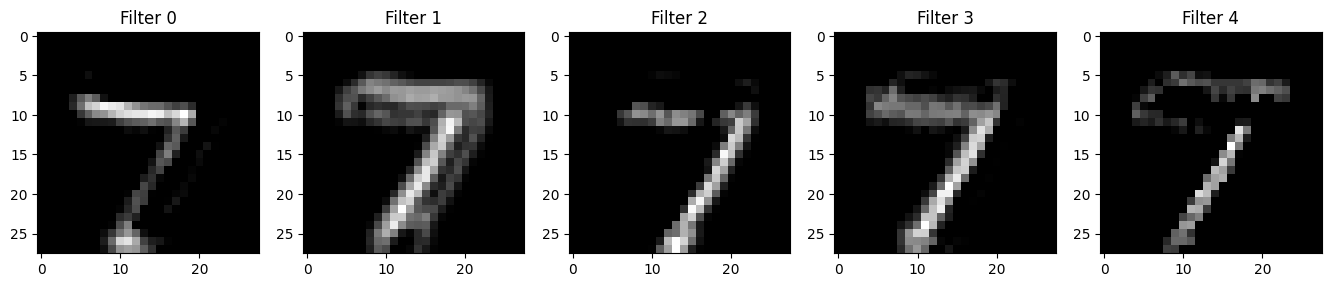

In [30]:
getActivations(model_tf2, model_tf2.layers[0].name, imageToUse_tf2)

### Activation in Layer 2

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step


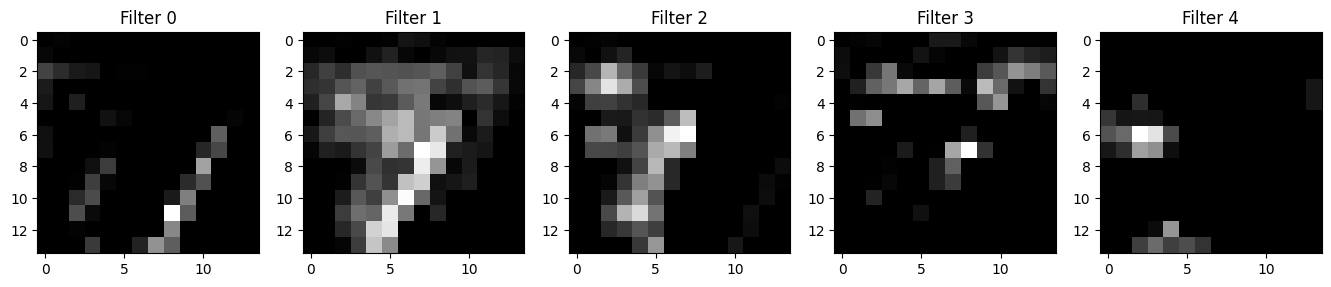

In [31]:
getActivations(model_tf2, model_tf2.layers[2].name, imageToUse_tf2)

### Activation in Layer 3

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step


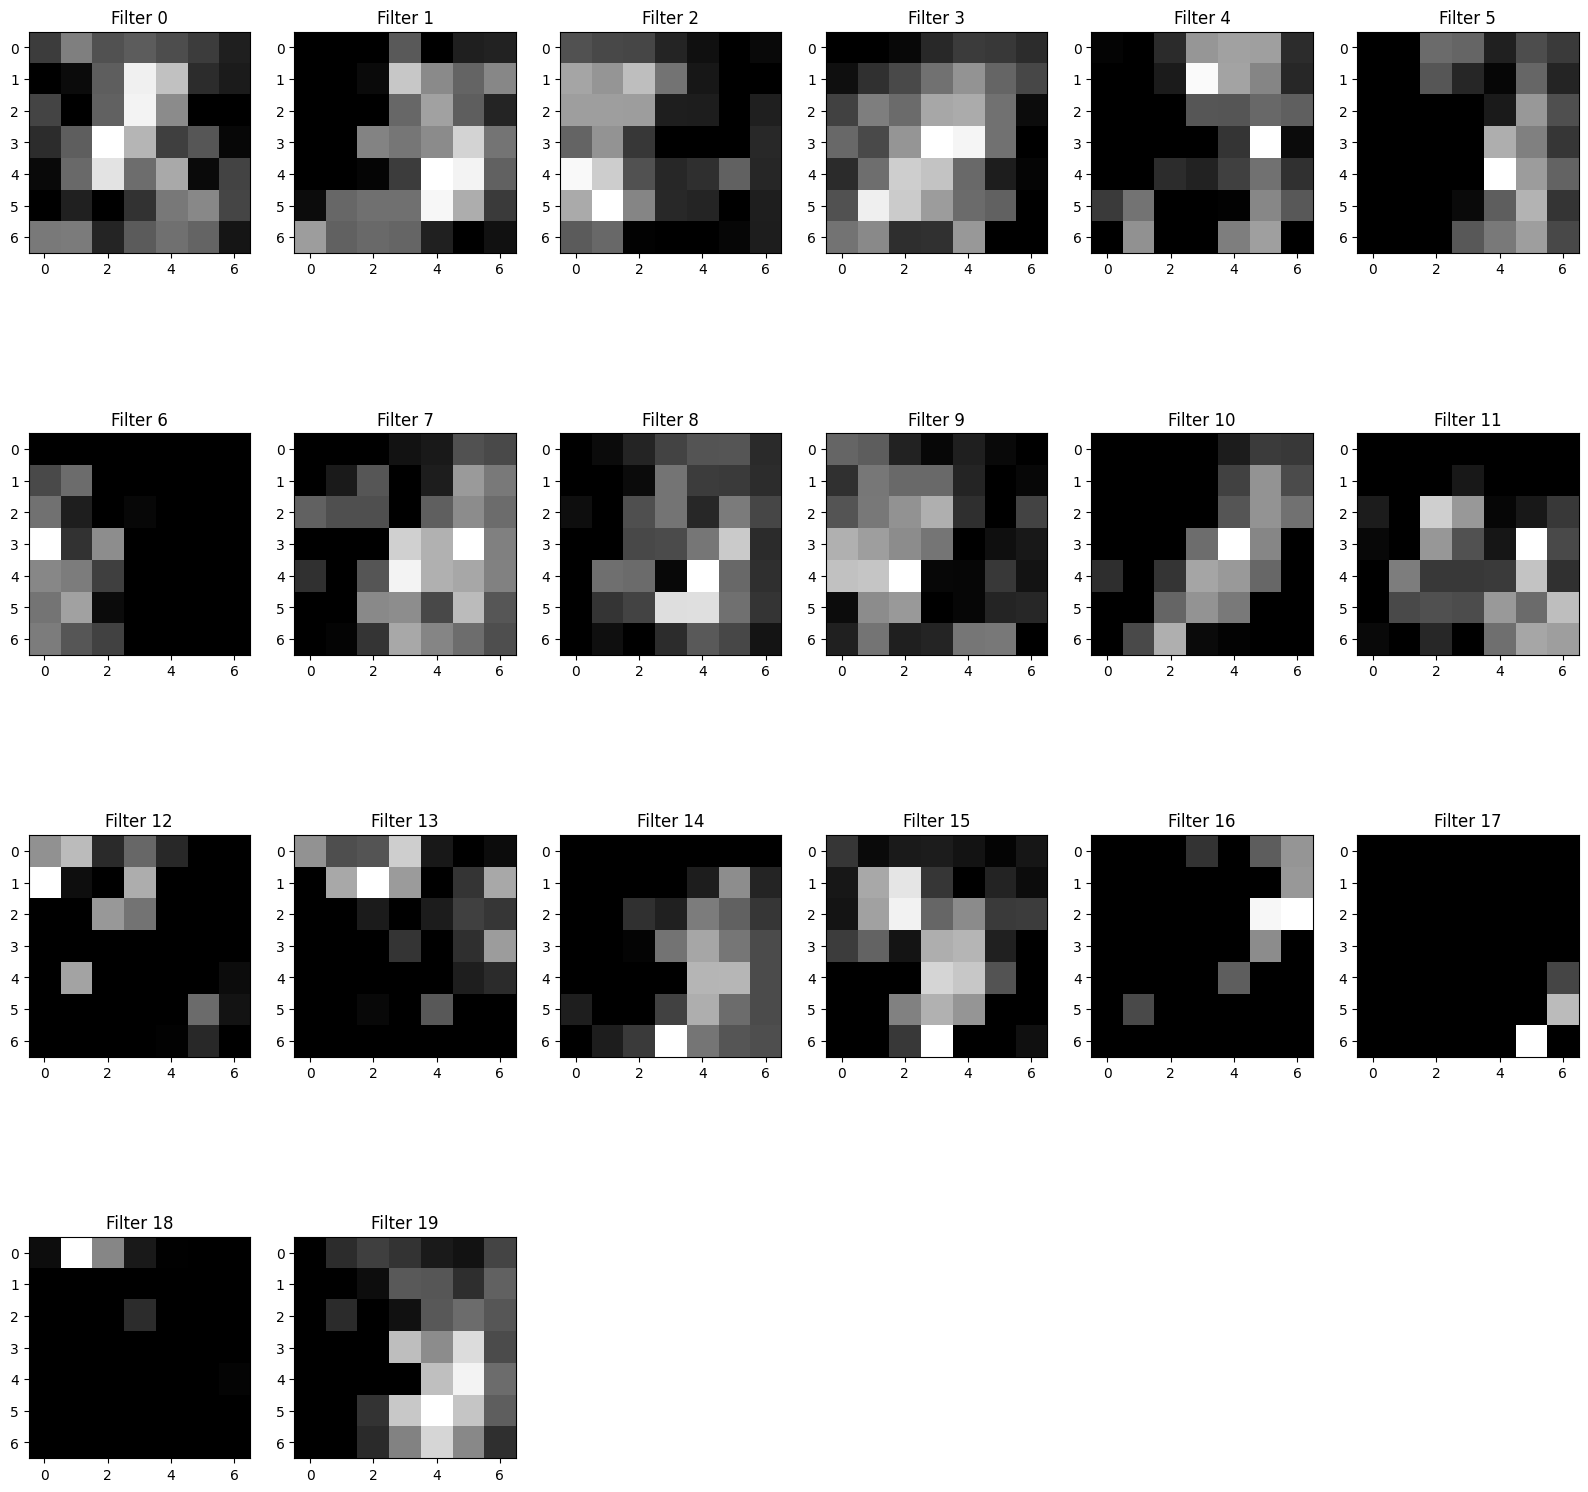

In [32]:
getActivations(model_tf2, model_tf2.layers[4].name, imageToUse_tf2)

# Part 4: Design Choices in Convolutional Neural Networks

## Influence of convolution size

### Model with (3 x 3) Convolution

In [33]:
K.clear_session()
start = timeit.default_timer()
model = Sequential()
model.add(Conv2D(8, kernel_size=(3, 3), activation='relu', input_shape=input_shape))
model.add(Conv2D(16, (3, 3), activation='relu'))
model.add(Flatten())
model.add(Dense(32, activation='relu'))
model.add(Dense(num_classes, activation='softmax'))
model.summary()
model.compile(loss=keras.losses.categorical_crossentropy, optimizer=keras.optimizers.Adadelta(), metrics=['accuracy'])
model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, verbose=1, validation_data=(x_test, y_test))
end = timeit.default_timer()
print("Time Taken to run the model:",end - start, "seconds")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │       294,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 296,522 (1.13 MB)

 Trainable params: 296,522 (1.13 MB)

 Non-trainable params: 0 (0.00 B)

469/469 ━━━━━━━━━━━━━━━━━━━━ 39s 80ms/step - accuracy: 0.1339 - loss: 2.2816 - val_accuracy: 0.2586 - val_loss: 2.2268
Time Taken to run the model: 43.228479578999895 seconds


### Model with (7 x 7) Convolution

In [34]:
K.clear_session()
start = timeit.default_timer()
model = Sequential()
model.add(Conv2D(8, kernel_size=(7, 7), activation='relu', input_shape=input_shape))
model.add(Conv2D(16, (7, 7), activation='relu'))
model.add(Flatten())
model.add(Dense(32, activation='relu'))
model.add(Dense(num_classes, activation='softmax'))
model.summary()
model.compile(loss=keras.losses.categorical_crossentropy, optimizer=keras.optimizers.Adadelta(), metrics=['accuracy'])
model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, verbose=1, validation_data=(x_test, y_test))
end = timeit.default_timer()
print("Time Taken to run the model:",end - start, "seconds")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 22, 22, 8)      │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 16)     │         6,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │       131,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,122 (539.54 KB)

 Trainable params: 138,122 (539.54 KB)

 Non-trainable params: 0 (0.00 B)

469/469 ━━━━━━━━━━━━━━━━━━━━ 67s 139ms/step - accuracy: 0.1155 - loss: 2.2992 - val_accuracy: 0.1566 - val_loss: 2.2851
Time Taken to run the model: 67.31381848899991 seconds


## Striding

### Model with (7 x 7) Convolution with 2 Steps

In [35]:
start = timeit.default_timer()
model = Sequential()
model.add(Conv2D(8, kernel_size=(7, 7), strides=2, activation='relu', input_shape=input_shape))
model.add(Conv2D(16, (7, 7), strides=2, activation='relu'))
model.add(Flatten())
model.add(Dense(32, activation='relu'))
model.add(Dense(num_classes, activation='softmax'))
model.summary()
model.compile(loss=keras.losses.categorical_crossentropy, optimizer=keras.optimizers.Adadelta(), metrics=['accuracy'])
model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, verbose=1, validation_data=(x_test, y_test))
end = timeit.default_timer()
print("Time Taken to run the model:",end - start, "seconds")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 11, 11, 8)      │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 3, 3, 16)       │         6,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 144)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,658 (45.54 KB)

 Trainable params: 11,658 (45.54 KB)

 Non-trainable params: 0 (0.00 B)

469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 23ms/step - accuracy: 0.1266 - loss: 2.3040 - val_accuracy: 0.1376 - val_loss: 2.3014
Time Taken to run the model: 12.86807881499999 seconds


## Padding

### Model with (7 x 7) Convolution with Same Padding

In [36]:
start = timeit.default_timer()
model = Sequential()
model.add(Conv2D(8, kernel_size=(7, 7), strides=1, padding='same', activation='relu', input_shape=input_shape))
model.add(Conv2D(16, (7, 7), strides=1, padding='same', activation='relu'))
model.add(Flatten())
model.add(Dense(32, activation='relu'))
model.add(Dense(num_classes, activation='softmax'))
model.summary()
model.compile(loss=keras.losses.categorical_crossentropy, optimizer=keras.optimizers.Adadelta(), metrics=['accuracy'])
model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, verbose=1, validation_data=(x_test, y_test))
end = timeit.default_timer()
print("Time Taken to run the model:",end - start, "seconds")

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 8)      │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 16)     │         6,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │       401,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 408,458 (1.56 MB)

 Trainable params: 408,458 (1.56 MB)

 Non-trainable params: 0 (0.00 B)

469/469 ━━━━━━━━━━━━━━━━━━━━ 186s 393ms/step - accuracy: 0.1609 - loss: 2.2848 - val_accuracy: 0.2944 - val_loss: 2.2501
Time Taken to run the model: 186.89712614100017 seconds


## Pooling

### Model with (3 x 3) Convolution with Pooling (2 x 2)

In [37]:
start = timeit.default_timer()
model = Sequential()
model.add(Conv2D(8, kernel_size=(3, 3), activation='relu', input_shape=input_shape))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(16, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(32, activation='relu'))
model.add(Dense(num_classes, activation='softmax'))
model.summary()
model.compile(loss=keras.losses.categorical_crossentropy, optimizer=keras.optimizers.Adadelta(), metrics=['accuracy'])
model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, verbose=1, validation_data=(x_test, y_test))
end = timeit.default_timer()
print("Time Taken to run the model:",end - start, "seconds")

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 26, 26, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 11, 11, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │        12,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,410 (56.29 KB)

 Trainable params: 14,410 (56.29 KB)

 Non-trainable params: 0 (0.00 B)

469/469 ━━━━━━━━━━━━━━━━━━━━ 23s 46ms/step - accuracy: 0.0597 - loss: 2.3122 - val_accuracy: 0.0643 - val_loss: 2.3093
Time Taken to run the model: 23.88409231699984 seconds


### Model with (3 x 3) Convolution with Pooling (3 x 3)

In [38]:
K.clear_session()
start = timeit.default_timer()
model = Sequential()
model.add(Conv2D(8, kernel_size=(3, 3), activation='relu', input_shape=input_shape))
model.add(MaxPooling2D(pool_size=(3, 3)))
model.add(Conv2D(16, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(3, 3)))
model.add(Flatten())
model.add(Dense(32, activation='relu'))
model.add(Dense(num_classes, activation='softmax'))
model.summary()
model.compile(loss=keras.losses.categorical_crossentropy, optimizer=keras.optimizers.Adadelta(), metrics=['accuracy'])
model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, verbose=1, validation_data=(x_test, y_test))
end = timeit.default_timer()
print("Time Taken to run the model:",end - start, "seconds")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 8, 8, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 6, 6, 16)       │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 2, 2, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,658 (14.29 KB)

 Trainable params: 3,658 (14.29 KB)

 Non-trainable params: 0 (0.00 B)

469/469 ━━━━━━━━━━━━━━━━━━━━ 18s 35ms/step - accuracy: 0.0973 - loss: 2.3063 - val_accuracy: 0.1011 - val_loss: 2.3033
Time Taken to run the model: 18.467800781999813 seconds


### What are your findings?